In [ ]:
!pip install seaborn pandas scikit-learn matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\NIKO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


¡Matriz calculada! Se guardó un archivo 'matriz_gigante_completa.png' en tu carpeta.


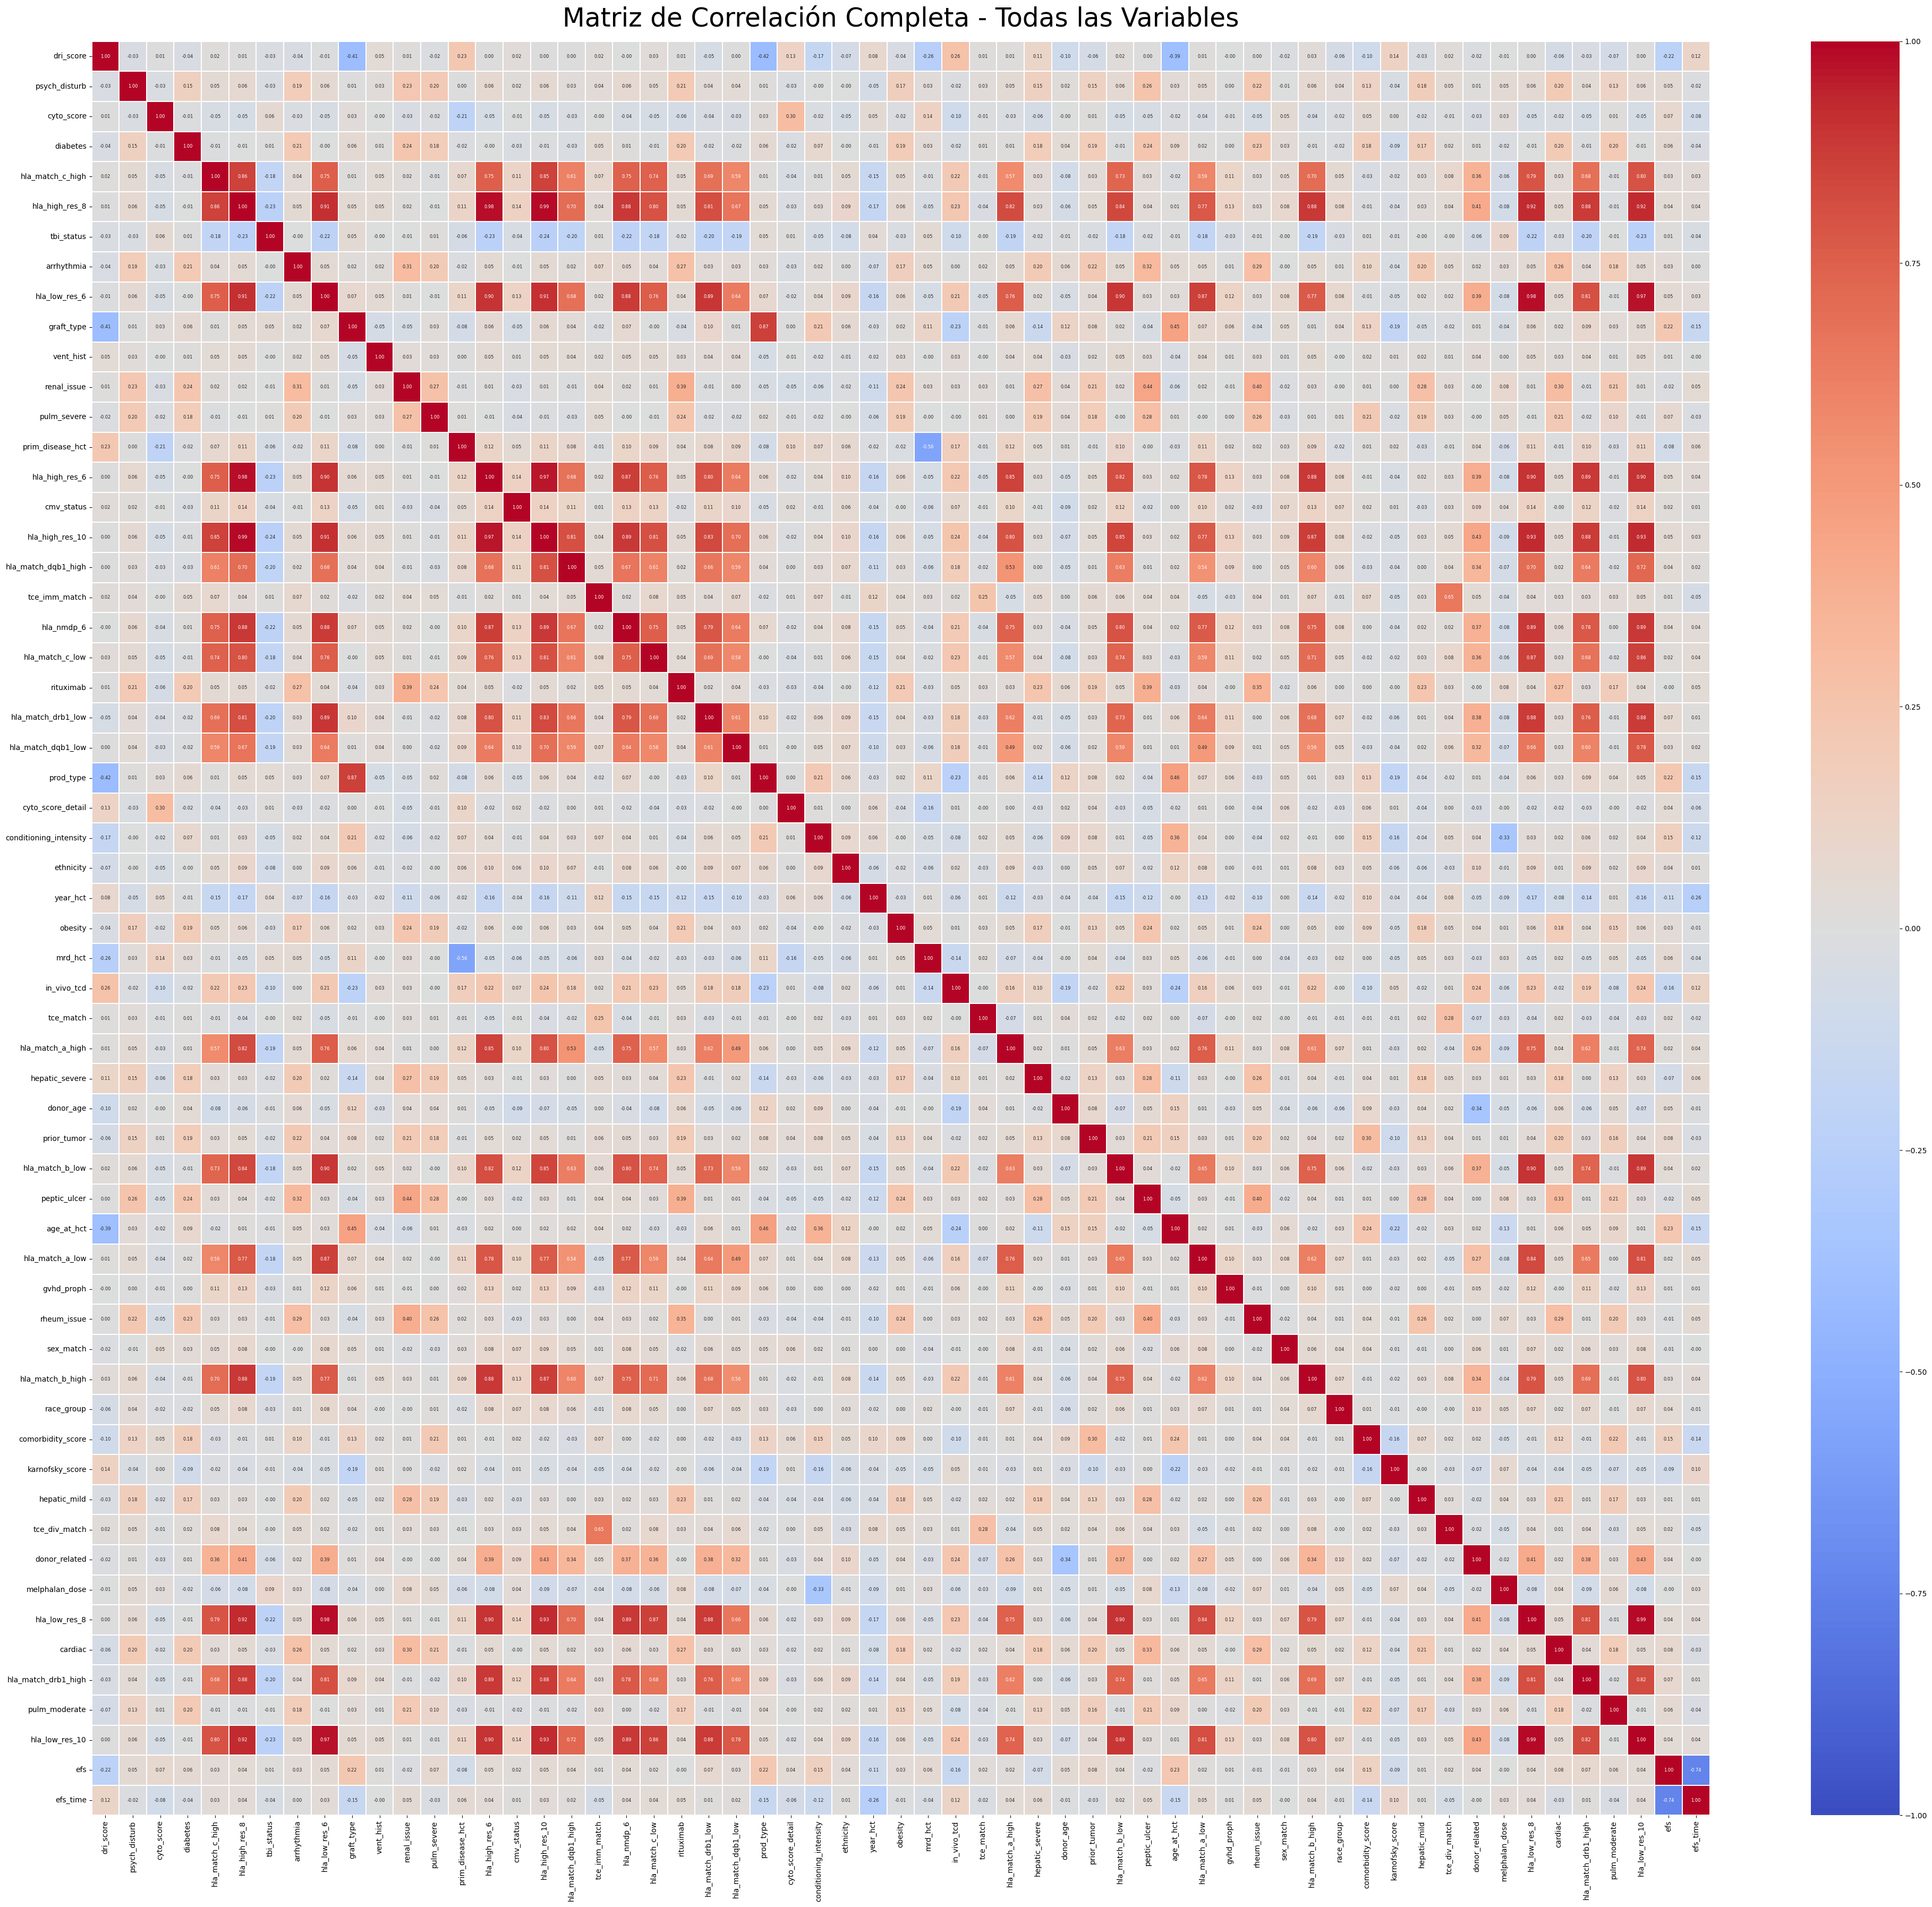

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# 1. Load data (relative path to repo)
ruta_archivo = Path('../ai_service/data/raw/train.csv').resolve()
if not ruta_archivo.exists():
    raise FileNotFoundError(f'File not found: {ruta_archivo}')

train = pd.read_csv(ruta_archivo)

# Create copy
df_corr = train.copy()

# Remove columns that do not contribute to feature correlation
for col in ['ID']:
    if col in df_corr.columns:
        df_corr = df_corr.drop(columns=[col])

# 2. Convert text variables to numbers
le = LabelEncoder()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = df_corr[col].fillna('Missing')
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# 3. Calculate full correlation matrix
corr_matrix_full = df_corr.corr(numeric_only=True)

# 4. Configure a large canvas
plt.figure(figsize=(40, 36))

# 5. Plot
sns.heatmap(
    corr_matrix_full,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot_kws={'size': 6},
    linewidths=0.1
)

plt.title('Full Correlation Matrix - All Variables', fontsize=35, pad=20)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 6. Save image
plt.savefig('matriz_gigante_completa.png', dpi=300)
print("Matrix calculated. File generated: 'matriz_gigante_completa.png'")

# Show in notebook
plt.show()

In [ ]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 1. Load data
# =========================
data_dir = Path('../ai_service/data/raw').resolve()
train_path = data_dir / 'train.csv'
test_path = data_dir / 'test.csv'

if not train_path.exists():
    raise FileNotFoundError(f'train.csv not found in: {train_path}')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path) if test_path.exists() else None

TARGET = 'efs_time'

# Avoid data leakage: exclude 'efs' when predicting efs_time
cols_to_drop = ['ID', TARGET, 'efs']
X = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
y = train[TARGET]

# =========================
# 2. Robust preprocessing
# =========================
# Pandas 3 compat: 'object' or 'category', remove 'str' from include
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ],
    remainder='drop'
)

# =========================
# 3. Train / Validation split
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. Pipeline with LassoCV
# =========================
pipeline = Pipeline([
    ('prep', preprocessor),
    ('lasso', LassoCV(cv=5, random_state=42, n_jobs=-1, max_iter=20000))
])

# Train model
pipeline.fit(X_train, y_train)

# =========================
# 5. Evaluation
# =========================
y_pred_val = pipeline.predict(X_val)

mse = mean_squared_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f'Validation MSE: {mse:.4f}')
print(f'Validation R2: {r2:.4f}')

best_alpha = pipeline.named_steps['lasso'].alpha_
print(f'Best alpha found: {best_alpha:.6f}')

# =========================
# 6. Interpretation (Feature Selection)
# =========================
feature_names = pipeline.named_steps['prep'].get_feature_names_out()
coef = pipeline.named_steps['lasso'].coef_
coef_series = pd.Series(coef, index=feature_names)

selected = coef_series[coef_series != 0]
removed = coef_series[coef_series == 0]

print(f'\nTotal variables post-encoding: {len(coef_series)}')
print(f'Selected variables (coef != 0): {len(selected)}')
print(f'Variables eliminated by Lasso (coef == 0): {len(removed)}')

print('\nTop 10 most important variables (|coef|):')
print(selected.abs().sort_values(ascending=False).head(10))

# =========================
# 7. Prediction on test set (optional)
# =========================
if test is not None:
    test_ids = test['ID'] if 'ID' in test.columns else pd.Series(range(len(test)), name='ID')
    X_test = test.drop(columns=[c for c in ['ID', 'efs', TARGET] if c in test.columns], errors='ignore')

    predicciones_test = pipeline.predict(X_test)

    submission = pd.DataFrame({
        'ID': test_ids,
        'prediction': predicciones_test
    })
    submission.to_csv('submission.csv', index=False)
    print("\nFile 'submission.csv' generated successfully.")
else:
    print('\ntest.csv does not exist in this repo; submission.csv generation was skipped.')

Validation MSE: 521.2430
Validation R2: 0.1637
Best alpha found: 0.013610

Total variables post-encoding: 183
Selected variables (coef != 0): 121
Variables eliminated by Lasso (coef == 0): 62

Top 10 most important variables (|coef|):
cat__ethnicity_Non-resident of the U.S.    7.505334
cat__prior_tumor_Not done                  6.941613
num__year_hct                              6.145963
cat__prim_disease_hct_IIS                  4.668077
cat__cardiac_Yes                           4.553559
cat__diabetes_Not done                     4.287774
cat__prim_disease_hct_AI                   4.225618
cat__conditioning_intensity_RIC            3.716819
cat__dri_score_High                        3.694607
cat__cmv_status_+/-                        3.418920
dtype: float64

test.csv does not exist in this repo; submission.csv generation was skipped.


In [ ]:
# =========================
# 8. Comparison with Actual Survival Model (Penalized Cox)
# =========================
# Since efs_time contains censored data, the optimal statistical approach is a penalized 
# Cox proportional hazards model.

try:
    from lifelines import CoxPHFitter
    from lifelines.utils import concordance_index
    import numpy as np

    print("--- Training Penalized Cox Model (Lifelines) ---")
    
    X_train_prep = preprocessor.transform(X_train)
    X_val_prep = preprocessor.transform(X_val)
    
    efs_train = train.loc[X_train.index, 'efs'].fillna(0).astype(int).values
    efs_val = train.loc[X_val.index, 'efs'].fillna(0).astype(int).values
    
    df_train_cox = pd.DataFrame(X_train_prep, columns=feature_names)
    df_train_cox['duration'] = y_train.values
    df_train_cox['event'] = efs_train
    
    # To avoid matrix singularity errors due to highly correlated variables or near-zero variance:
    # 1. Remove constant or quasi-constant columns
    variances = df_train_cox.var()
    cols_to_keep = variances[variances > 0.01].index.tolist()
    if 'duration' not in cols_to_keep: cols_to_keep.append('duration')
    if 'event' not in cols_to_keep: cols_to_keep.append('event')
    
    df_train_cox = df_train_cox[cols_to_keep]
    
    # Instantiate penalized Cox model with Elastic Net (L1 and L2) for numerical stability
    # penalizer controls the strength, l1_ratio=0.5 balances Lasso and Ridge
    cph = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
    cph.fit(df_train_cox, duration_col='duration', event_col='event', show_progress=False)
    
    # Evaluation with Concordance Index (C-Index)
    df_val_cox = pd.DataFrame(X_val_prep, columns=feature_names)
    df_val_cox['duration'] = y_val.values
    df_val_cox['event'] = efs_val
    df_val_cox = df_val_cox[cols_to_keep]

    c_index_train = cph.score(df_train_cox, scoring_method="concordance_index")
    c_index_val = cph.score(df_val_cox, scoring_method="concordance_index")
    
    print(f"C-index in training: {c_index_train:.4f}")
    print(f"C-index in validation: {c_index_val:.4f}")
    
    # Selected variables
    cph_coef = cph.params_
    cph_selected = cph_coef[cph_coef != 0]
    print(f"\nVariables selected by Penalized Cox: {len(cph_selected)} de {len(cph_coef)}")
    print("\nTop 10 highest risk variables (Penalized Cox - log(HR)):")
    print(cph_selected.abs().sort_values(ascending=False).head(10))
    
except Exception as e:
    print(f"Could not complete the Cox model: {str(e)}")
    print("Regular Lasso is sufficient for now, but keep in mind that it doesn't handle censored data perfectly.")

--- Training Penalized Cox Model (Lifelines) ---
C-index in training: 0.6385
C-index in validation: 0.6434

Variables selected by Penalized Cox: 141 de 141

Top 10 highest risk variables (Penalized Cox - log(HR)):
covariate
cat__dri_score_High                    0.271207
cat__prim_disease_hct_IEA              0.121524
cat__conditioning_intensity_RIC        0.118284
cat__cyto_score_detail_Poor            0.111428
cat__prim_disease_hct_IIS              0.097171
num__comorbidity_score                 0.085078
cat__conditioning_intensity_MAC        0.069109
cat__cyto_score_detail_Intermediate    0.068905
num__age_at_hct                        0.060094
cat__prod_type_BM                      0.058819
Name: coef, dtype: float64
